In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
import warnings

In [ ]:
tips=sns.load_dataset("tips")
df=pd.DataFrame(tips)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Preprocessing and Exploratory Data Analysis**


checking for missing data

In [ ]:
df .isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


Viewing the descriptive statistics of the dataset

In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Get a numerical summary for 'tip'

In [ ]:
df.tip.describe ()

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


Five Number Summary For bill and tip

In [ ]:
bill = df.total_bill
print("Maximum Bill", np.max(bill))
print("Minimum Bill", np.min (bill))
print("Standard Deviation",np.std(bill))
print("Median", np.median (bill))
print("Mean ",np.mean (bill))

Maximum Bill 50.81
Minimum Bill 3.07
Standard Deviation 8.88415057777113
Median 17.795
Mean  19.78594262295082


In [ ]:
tip = df.tip
print("Maximum Tip",np.max(tip))
print("Minimum Tip",np.min(tip))
print("Standard Deviation", np.std(tip))
print("Median", np.median (tip))
print("Mean", np.mean(tip))

Maximum Tip 10.0
Minimum Tip 1.0
Standard Deviation 1.3807999538298958
Median 2.9
Mean 2.99827868852459


**Exploratory data analysis**

Explore if there is any dependency between the variable "Tip" and rest of the variables.

sex
Male      157
Female     87
Name: count, dtype: int64


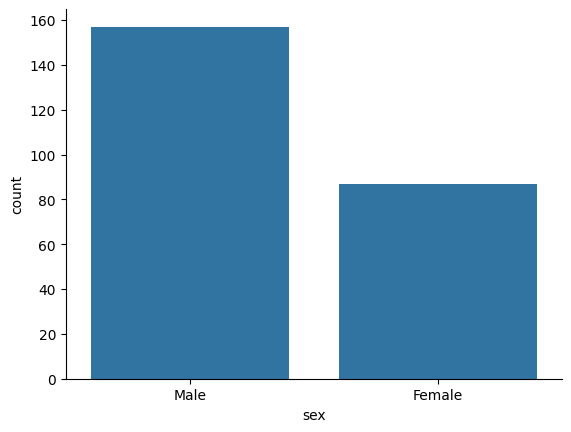

In [ ]:
sns.countplot(x='sex', data=tips)
sns.despine()
print(tips.sex.value_counts())

<Axes: xlabel='sex', ylabel='count'>

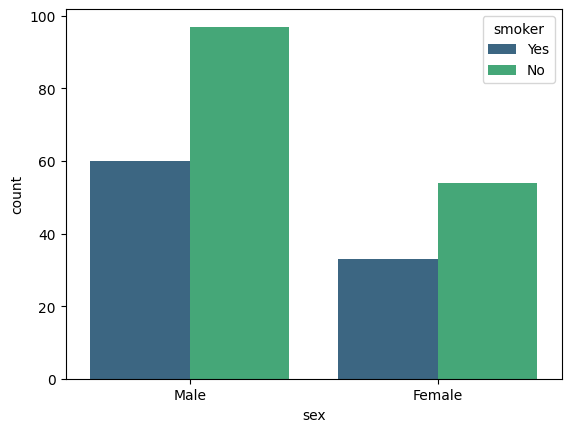

In [ ]:
sns.countplot(x='sex', data=tips,hue='smoker',palette='viridis')

<Axes: title={'center': 'Tips Per Day of Week'}, xlabel='day', ylabel='count'>

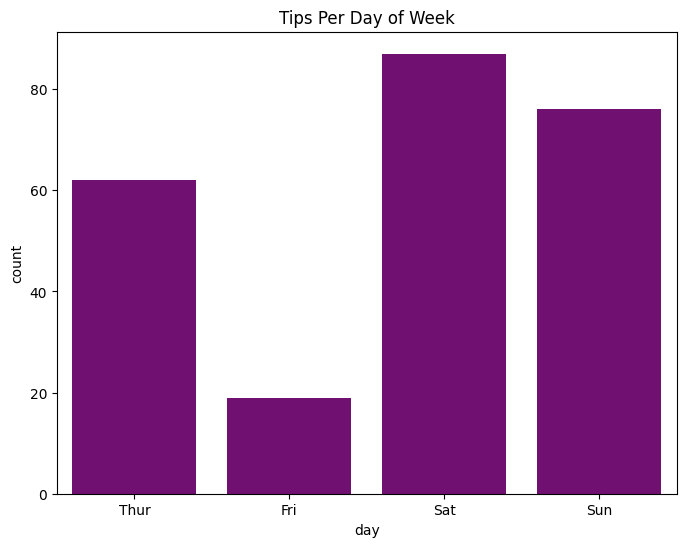

In [ ]:
plt.figure(figsize=(8,6))
plt.title("Tips Per Day of Week")
sns.countplot(x=tips['day'], color='purple')

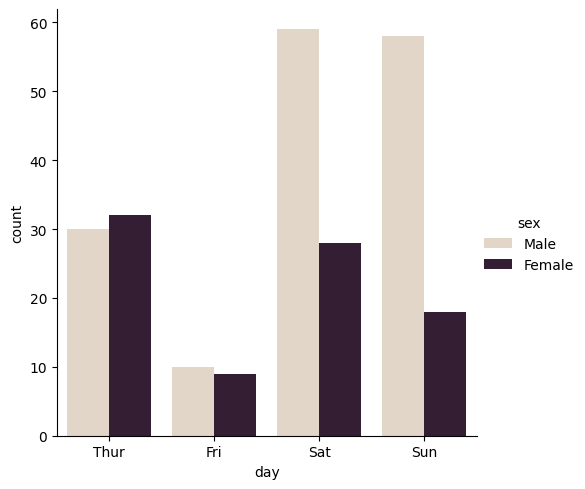

In [ ]:
sns.catplot(x='day', data=tips, hue='sex', palette='ch:.25', kind='count')

/tmp/ipython-input-4235560333.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['tip'])


<Axes: xlabel='tip', ylabel='Density'>

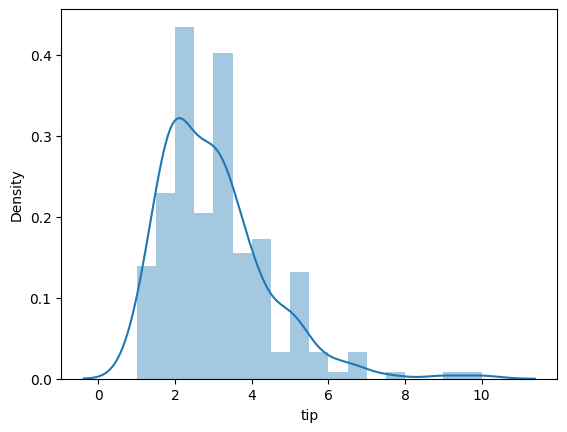

In [ ]:
sns.distplot(df['tip'])

/tmp/ipython-input-3285143343.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g=sns.distplot(tips.tip, kde=False)


Text(0.5, 1.0, 'Tip Amount Histogram')

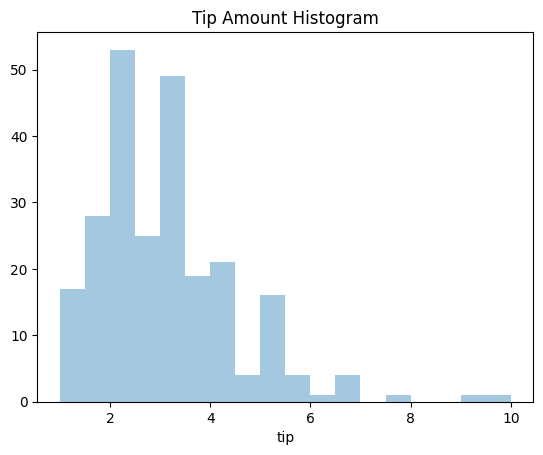

In [ ]:
g=sns.distplot(tips.tip, kde=False)
g.set_title('Tip Amount Histogram')

<Axes: xlabel='total_bill'>

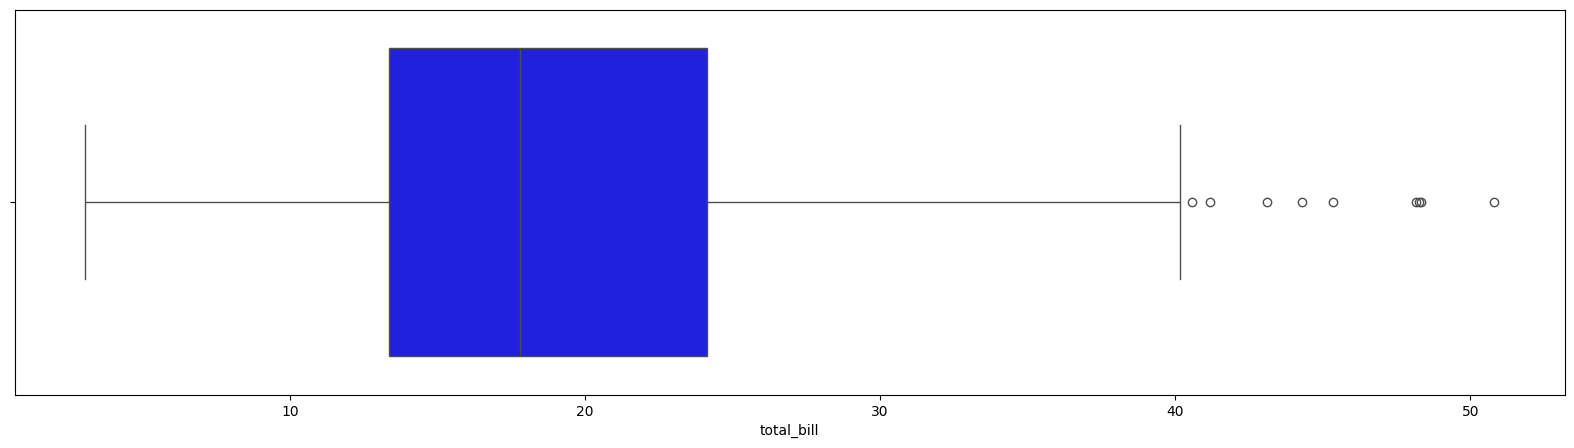

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x=bill, color='b')

outliers in tip column

<Axes: xlabel='tip'>

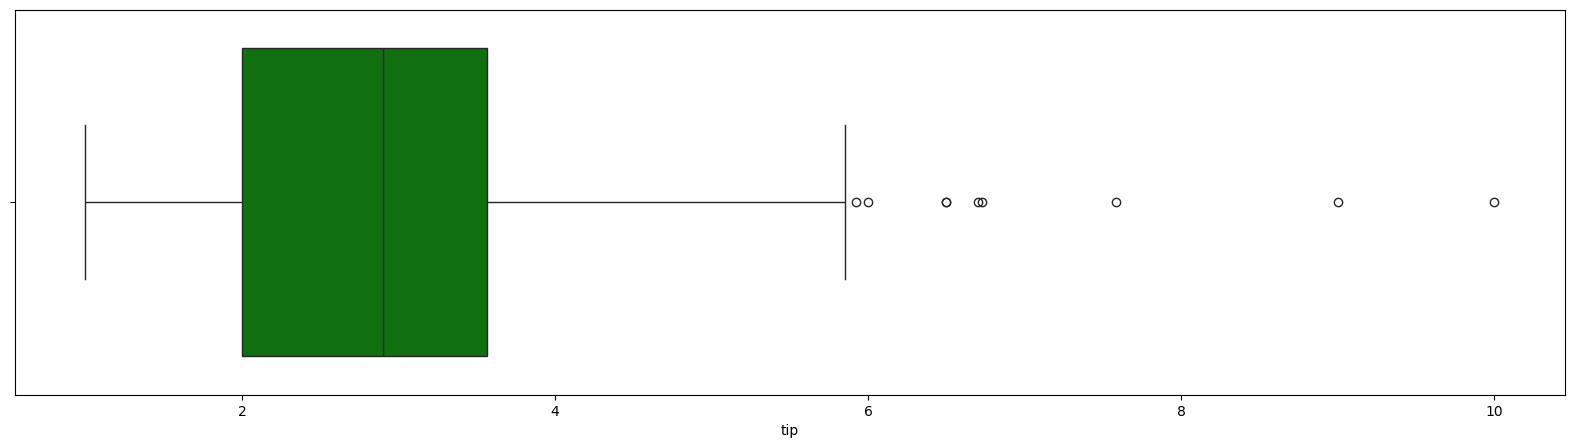

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(x=tip, color='g')

IQR value

In [ ]:
bill_tip = pd.DataFrame(df,columns=['total_bill', 'tip', 'size'])
print(bill_tip)
print("IQR For Total Bill: ",stats.iqr(bill))
print("IQR For Tip: ",stats.iqr(tip))

     total_bill   tip  size
0         16.99  1.01     2
1         10.34  1.66     3
2         21.01  3.50     3
3         23.68  3.31     2
4         24.59  3.61     4
..          ...   ...   ...
239       29.03  5.92     3
240       27.18  2.00     2
241       22.67  2.00     2
242       17.82  1.75     2
243       18.78  3.00     2

[244 rows x 3 columns]
IQR For Total Bill:  10.779999999999998
IQR For Tip:  1.5625


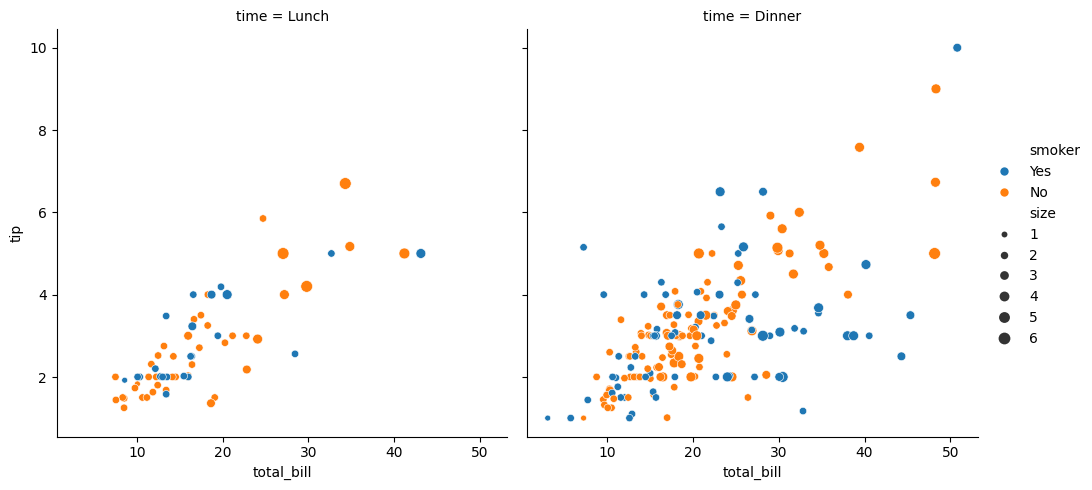

In [ ]:
sns.relplot(x='total_bill',y='tip',data=df,col='time', hue='smoker',size='size')

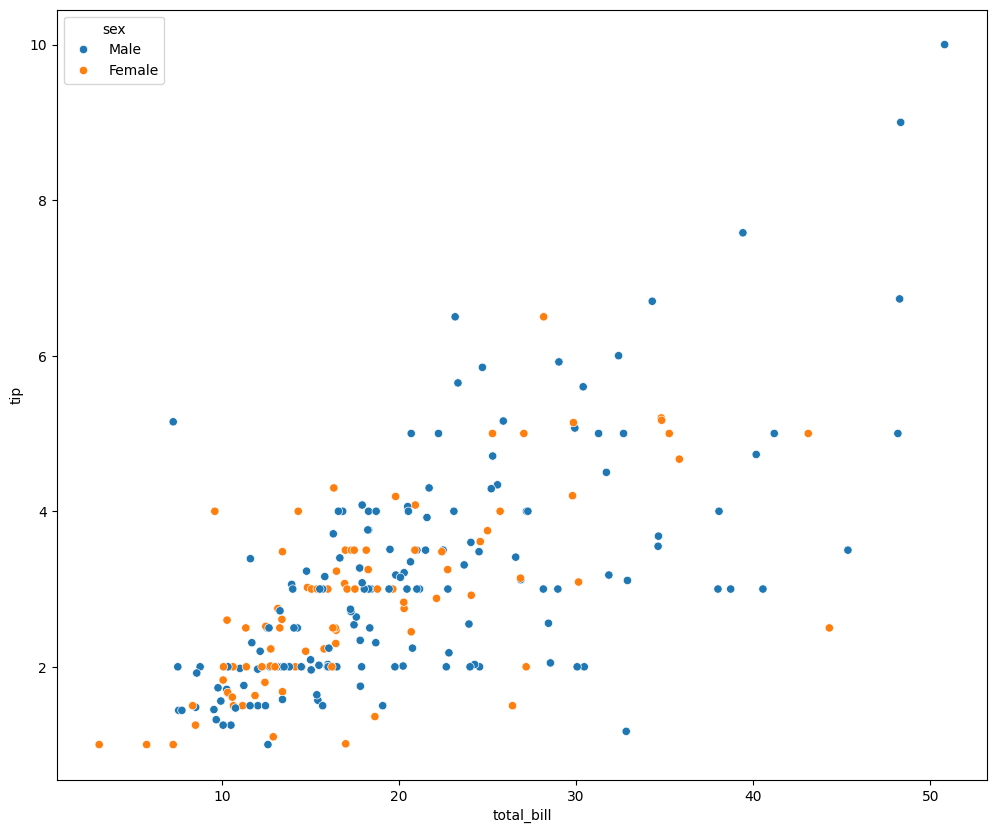

In [ ]:
plt.figure(figsize=(12,10))
sns.scatterplot (data=df,x="total_bill",y="tip", hue="sex");

Can see a linaer pattern ie as total bill increases tip also increases.

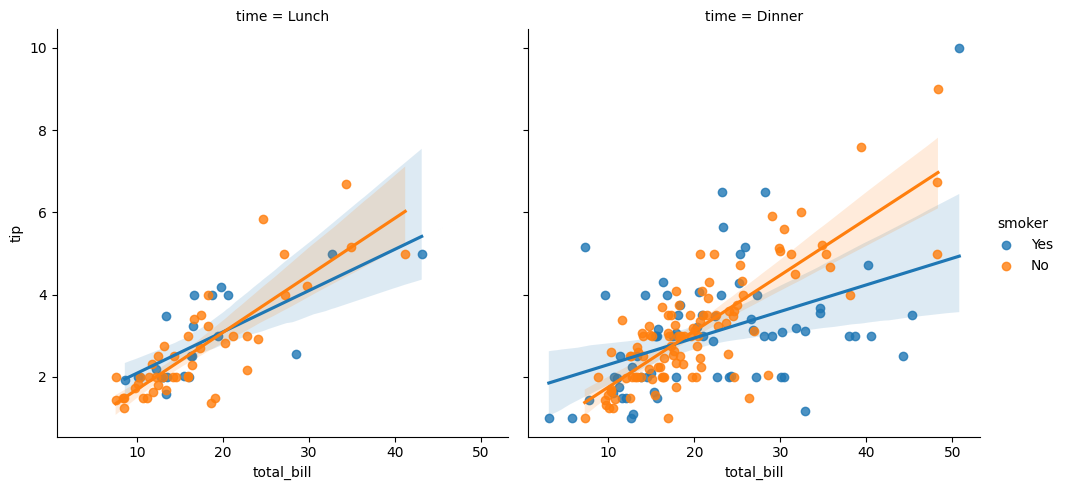

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=df,col='time', hue='smoker')

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


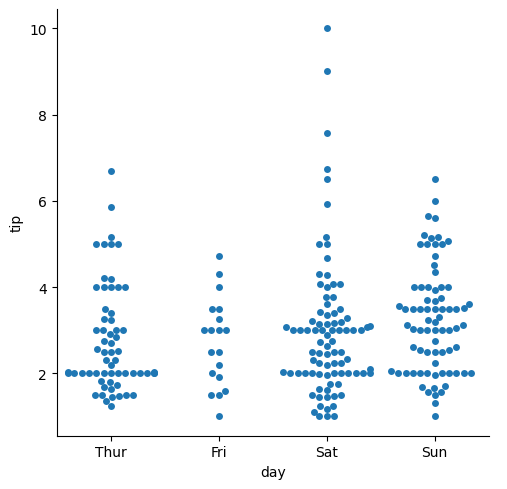

In [ ]:
sns.catplot(x='day',y='tip',data=df,kind='swarm')

/tmp/ipython-input-1738714062.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="time", y="tip", data=df, height=6, kind="bar", palette="muted")


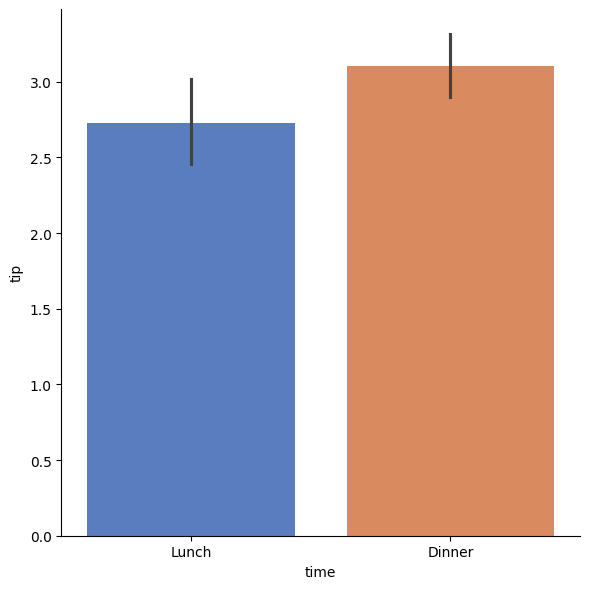

In [ ]:
sns.catplot(x="time", y="tip", data=df, height=6, kind="bar", palette="muted")

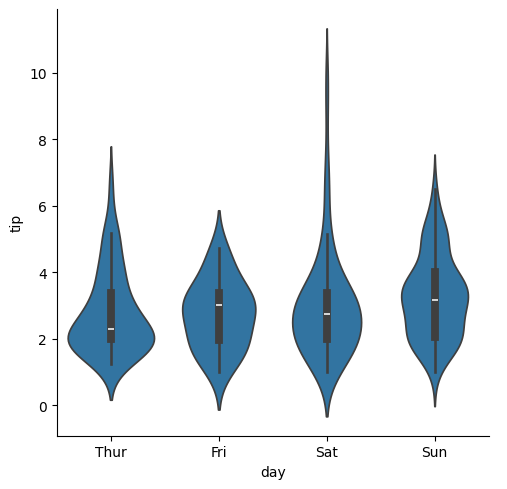

In [ ]:
sns.catplot(x='day',y='tip', data=df,kind="violin")

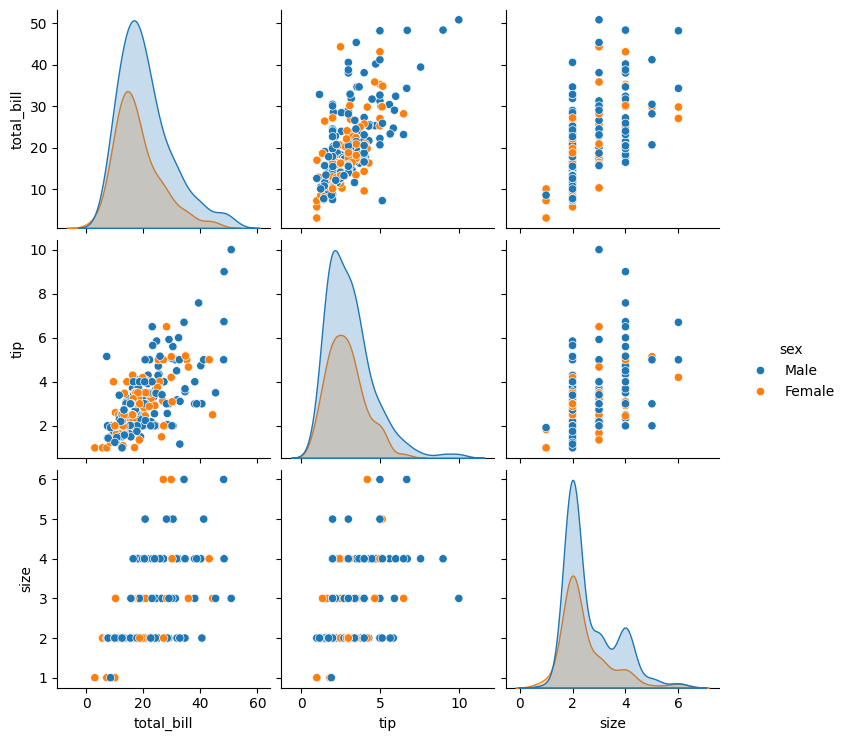

In [ ]:
sns.pairplot(df, hue='sex')

In [ ]:
# Inference: The pairplot reveals several key insights into the relationships between numerical variables, differentiated by gender:
# Male customers (blue points) are more numerous and exhibit a wider spread, particularly at higher `total_bill` and `tip` values.
# Their distributions for these variables tend to extend further than those of female customers.
# Female customers (orange points) are present across the spectrum but are less frequently associated with the very highest `total_bill` and `tip` amounts.
# For instance, `total_bill` and `tip` both appear right-skewed for both genders, indicating more frequent smaller values and fewer large values.

Correlation Matrix

(3.5, -0.5)

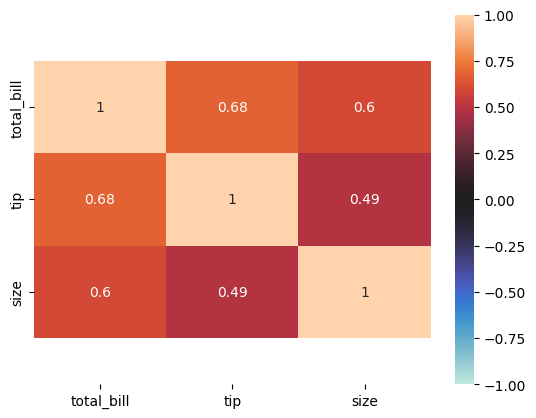

In [ ]:
corr_matrix=df.corr(numeric_only=True)
ax=sns.heatmap(data=corr_matrix,annot=True,vmax=1,vmin=-1,center=0)
bottom, top=ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

Converting categorical variables into numerical values so that the machine learning model can understand.

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder_df=LabelEncoder()
df['sex']=labelencoder_df.fit_transform(df['sex'])
df['smoker']=labelencoder_df.fit_transform(df['smoker'])
df['day']=labelencoder_df.fit_transform(df['day'])
df['time']=labelencoder_df.fit_transform(df['time'])
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [ ]:
# Inference:
# This transformation is essential for preparing the data for machine learning models, as they typically require numerical input rather than
# text-based categories.

Creating heatmap including these numerical values

(7.5, -0.5)

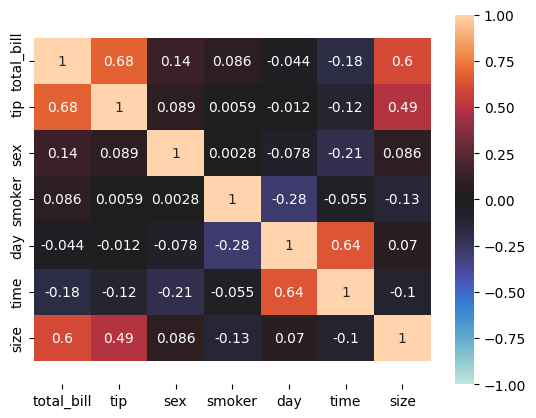

In [ ]:
corr_matrix=df.corr(numeric_only=True)
ax=sns.heatmap(data=corr_matrix,annot=True,vmax=1,vmin=-1,center=0)
bottom, top=ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

In [ ]:
# The ideal scenario would be serving a larger group of non-smoking male customers during dinner on a Saturday or Sunday,
# as they are most likely to incur a high total bill and leave a substantial tip.